In [1]:
import pandas as  pd

In [3]:
df=pd.read_csv('/Users/yangzhengkai/Downloads/customer_purchase_data.csv')

In [5]:
df.head()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


In [7]:
df.tail()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
1495,39,1,65048.141834,13,0,34.590743,0,5,1
1496,67,1,28775.331069,18,2,17.625707,0,1,1
1497,40,1,57363.247541,7,4,12.206033,0,0,0
1498,63,0,134021.775532,16,2,37.311634,1,0,1
1499,50,0,52625.665974,13,0,25.348017,1,4,1


In [9]:
df.isna().sum()

Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64

In [13]:
df.columns=df.columns.str.lower()
df.columns

Index(['age', 'gender', 'annualincome', 'numberofpurchases', 'productcategory',
       'timespentonwebsite', 'loyaltyprogram', 'discountsavailed',
       'purchasestatus'],
      dtype='object')

In [21]:
all_groupby=df.groupby('purchasestatus').mean()
all_groupby

,age,gender,annualincome,numberofpurchases,productcategory,timespentonwebsite,loyaltyprogram,discountsavailed
purchasestatus,,,,,,,,
0,47.762911,0.503521,78074.638282,9.276995,2.003521,26.365784,0.199531,2.104460
1,39.743827,0.506173,92367.522671,11.922840,2.024691,35.864062,0.493827,3.148148


In [117]:
all_groupby.to_csv('grouped_summary.csv')

In [92]:
df_groupby=df.groupby('purchasestatus').agg(['mean', 'count', 'std']).unstack()
df_groupby.to_csv('grouped_summary.csv')

In [42]:
df.groupby('purchasestatus')['gender'].mean()

purchasestatus
0    0.503521
1    0.506173
Name: gender, dtype: float64

In [48]:
df.groupby('productcategory')['purchasestatus'].mean()

productcategory
0    0.404844
1    0.450151
2    0.424908
3    0.465035
4    0.414330
Name: purchasestatus, dtype: float64

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       172
           1       0.98      0.90      0.94       128

    accuracy                           0.95       300
   macro avg       0.96      0.94      0.95       300
weighted avg       0.95      0.95      0.95       300



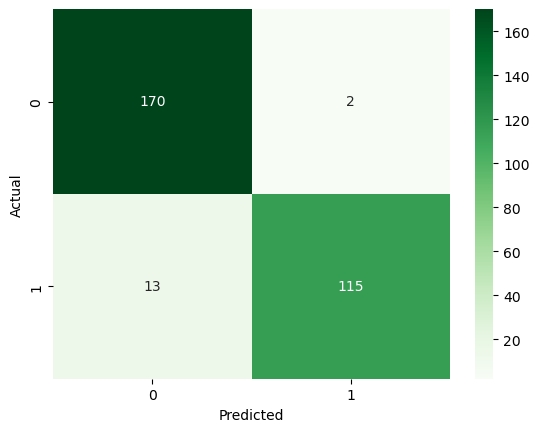

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 拿掉 gender
X = df.drop(['purchasestatus', 'gender'], axis=1)
y = df['purchasestatus']

# 切資料
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 建模型
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 預測
y_pred_rf = rf.predict(X_test)

# 印報表
print(classification_report(y_test, y_pred))

# 畫 confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

              precision    recall  f1-score   support

           0       0.82      0.92      0.87       172
           1       0.88      0.72      0.79       128

    accuracy                           0.84       300
   macro avg       0.85      0.82      0.83       300
weighted avg       0.84      0.84      0.83       300



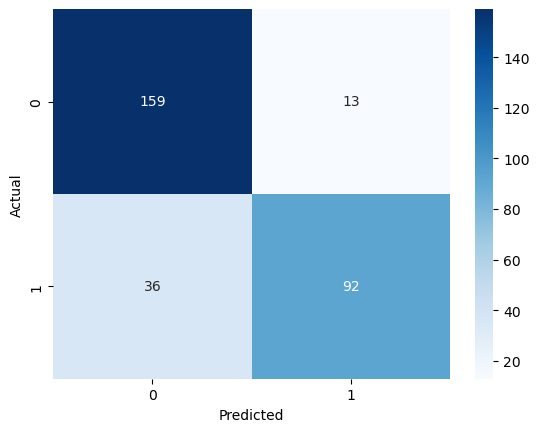

In [70]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 建模
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 預測
y_pred_lr = log_reg.predict(X_test_scaled)

# 評估
print(classification_report(y_test, y_pred_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

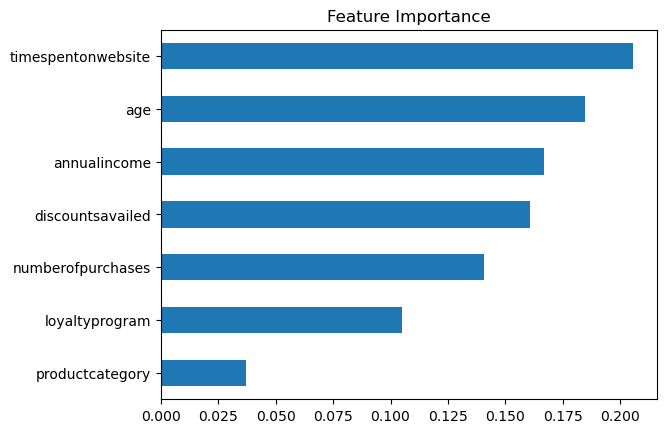

In [109]:
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()

In [111]:
plt.savefig('Feature Importance.png')

<Figure size 640x480 with 0 Axes>

In [78]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Logistic 的表現
log_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr)
}

# RandomForest 的表現
rf_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf)
}

# 放到一個表格
df_compare = pd.DataFrame([log_metrics, rf_metrics], index=['Logistic', 'RandomForest'])
print(df_compare)

              accuracy  precision    recall        f1
Logistic      0.836667   0.876190  0.718750  0.789700
RandomForest  0.950000   0.982906  0.898438  0.938776


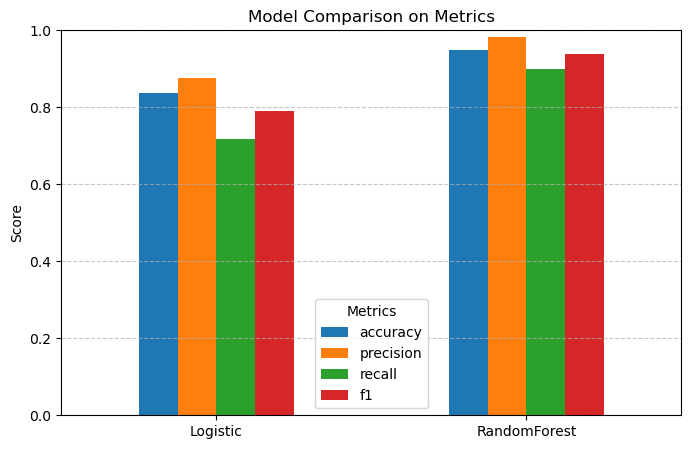

In [80]:
df_compare.plot(kind='bar', figsize=(8,5))
plt.title('Model Comparison on Metrics')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [96]:
pd.DataFrame(log_reg.coef_, columns=X_train.columns)

,age,annualincome,numberofpurchases,productcategory,timespentonwebsite,loyaltyprogram,discountsavailed
0,-1.004259,0.723848,0.600777,-0.13247,1.034254,1.127607,1.153428


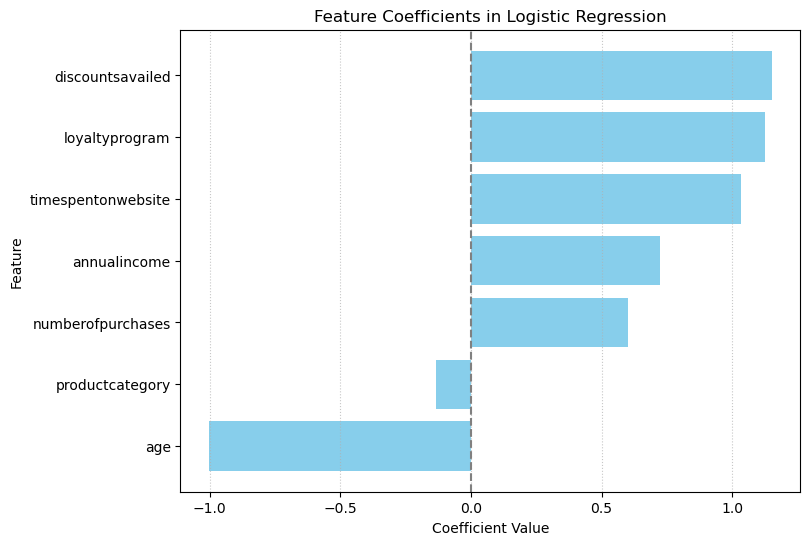

In [99]:
coef_df = pd.DataFrame(log_reg.coef_, columns=X_train.columns).T
coef_df.columns = ['Coefficient']

# 排序
coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=True)

# 繪圖
plt.figure(figsize=(8,6))
plt.barh(coef_df_sorted.index, coef_df_sorted['Coefficient'], color='skyblue')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Feature Coefficients in Logistic Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.show()

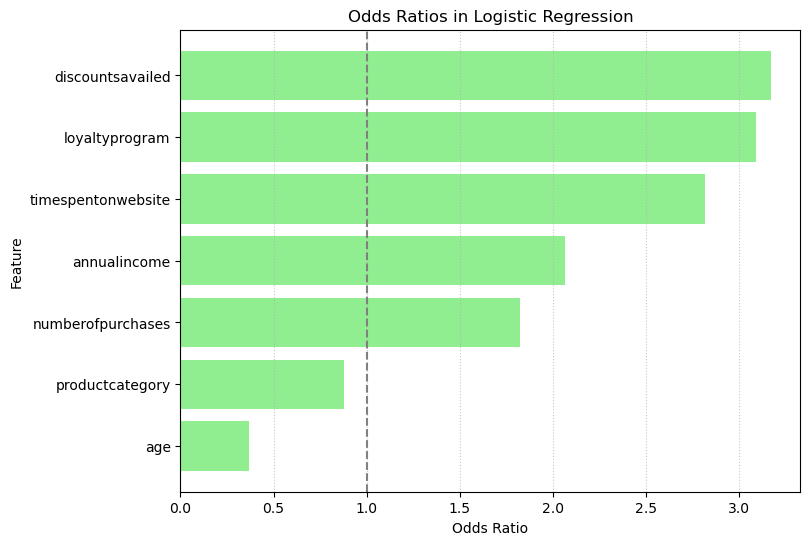

In [105]:
import numpy as np
odds_ratios = np.exp(log_reg.coef_[0])

# 做成 DataFrame
or_df = pd.DataFrame({'Odds Ratio': odds_ratios}, index=X_train.columns)
or_df_sorted = or_df.sort_values(by='Odds Ratio', ascending=True)

# 畫 barh 圖
plt.figure(figsize=(8,6))
plt.barh(or_df_sorted.index, or_df_sorted['Odds Ratio'], color='lightgreen')
plt.axvline(1, color='gray', linestyle='--')  # OR=1 代表無影響
plt.title('Odds Ratios in Logistic Regression')
plt.xlabel('Odds Ratio')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.show()

In [107]:
plt.savefig('Odds Ratios in Logistic Regression.png')

<Figure size 640x480 with 0 Axes>

In [101]:
plt.savefig('Feature Coefficients in Logistic Regression.png')

<Figure size 640x480 with 0 Axes>

In [82]:
plt.savefig('model_comparison.png')

<Figure size 640x480 with 0 Axes>

In [113]:
df_compare.to_csv('model_compare_metrics.csv', index=True)

In [115]:
df.compare

<bound method DataFrame.compare of       age  gender   annualincome  numberofpurchases  productcategory  \
0      40       1   66120.267939                  8                0   
1      20       1   23579.773583                  4                2   
2      27       1  127821.306432                 11                2   
3      24       1  137798.623120                 19                3   
4      31       1   99300.964220                 19                1   
...   ...     ...            ...                ...              ...   
1495   39       1   65048.141834                 13                0   
1496   67       1   28775.331069                 18                2   
1497   40       1   57363.247541                  7                4   
1498   63       0  134021.775532                 16                2   
1499   50       0   52625.665974                 13                0   

      timespentonwebsite  loyaltyprogram  discountsavailed  purchasestatus  
0              30.56860